In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Setup Paths
root = Path().resolve().parent
ONET_DIR = root / "data" / "raw" / "onet"

# 2. Load the data
df_occ = pd.read_csv(ONET_DIR / "Occupation Data.txt", sep='\t')
df_skills = pd.read_csv(ONET_DIR / "Skills.txt", sep='\t')
df_tasks = pd.read_csv(ONET_DIR / "Task Statements.txt", sep='\t')

print(f"✅ Data Ready: {len(df_occ)} Occupations, {len(df_skills)} Skill rows , {len(df_tasks)} task rows")
print(df_skills.head())
print(df_occ.head())
print(df_tasks.head())

✅ Data Ready: 1016 Occupations, 62580 Skill rows , 18796 task rows
  O*NET-SOC Code Element ID           Element Name Scale ID  Data Value  N  \
0     11-1011.00    2.A.1.a  Reading Comprehension       IM        4.12  8   
1     11-1011.00    2.A.1.a  Reading Comprehension       LV        4.62  8   
2     11-1011.00    2.A.1.b       Active Listening       IM        4.00  8   
3     11-1011.00    2.A.1.b       Active Listening       LV        4.75  8   
4     11-1011.00    2.A.1.c                Writing       IM        4.12  8   

   Standard Error  Lower CI Bound  Upper CI Bound Recommend Suppress  \
0          0.1250          3.8800          4.3700                  N   
1          0.1830          4.2664          4.9836                  N   
2          0.0000          4.0000          4.0000                  N   
3          0.1637          4.4292          5.0708                  N   
4          0.1250          3.8800          4.3700                  N   

  Not Relevant     Date Domain 

In [2]:
# Count tasks per occupation
task_counts = df_tasks.groupby('O*NET-SOC Code').size().sort_values(ascending=False)

# Merge with titles to make it readable
top_task_jobs = task_counts.head(10).to_frame(name='Task Count').merge(
    df_occ[['O*NET-SOC Code', 'Title']], on='O*NET-SOC Code'
)

print("🚀 Jobs with the most unique tasks:")
print(top_task_jobs[['Title', 'Task Count']])

🚀 Jobs with the most unique tasks:
                                               Title  Task Count
0          Special Education Teachers, Middle School          40
1       Special Education Teachers, Secondary School          40
2  Telecommunications Equipment Installers and Re...          39
3                              Industrial Ecologists          38
4  Elementary School Teachers, Except Special Edu...          38
5         Aircraft Mechanics and Service Technicians          38
6  Adult Basic Education, Adult Secondary Educati...          37
7    Kindergarten Teachers, Except Special Education          37
8              Special Education Teachers, Preschool          36
9                       Search Marketing Strategists          36


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8636\1917626343.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Data Value', y='Element Name', data=dev_skills, palette='viridis')


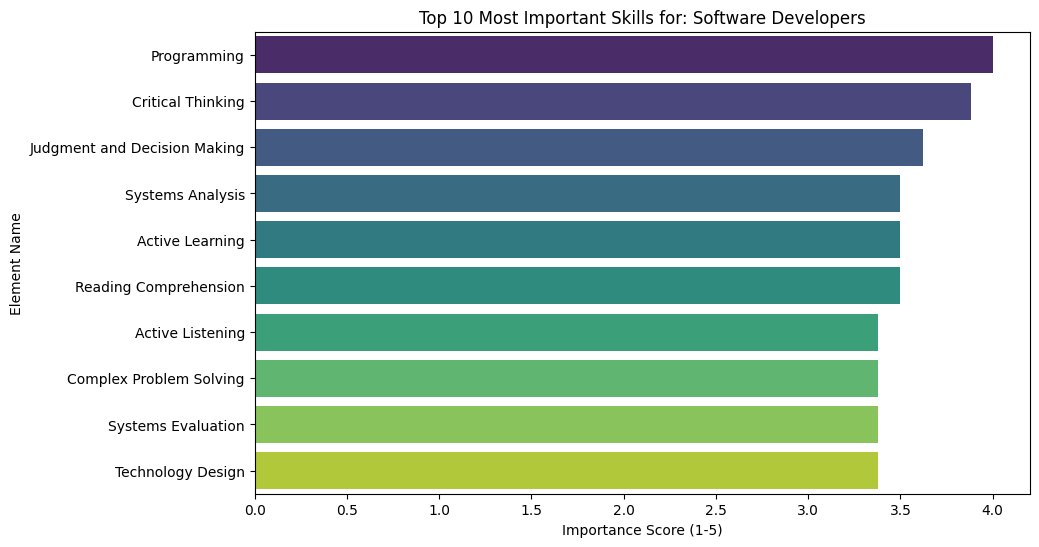

In [3]:
# 1. Find the code for Software Developers
dev_code = df_occ[df_occ['Title'].str.contains("Software Developers", case=False)]['O*NET-SOC Code'].values[0]

# 2. Get Skills for that code (Focusing on Importance 'IM')
dev_skills = df_skills[(df_skills['O*NET-SOC Code'] == dev_code) & (df_skills['Scale ID'] == 'IM')]
dev_skills = dev_skills.sort_values(by='Data Value', ascending=False).head(10)

# 3. Plot it!
plt.figure(figsize=(10, 6))
sns.barplot(x='Data Value', y='Element Name', data=dev_skills, palette='viridis')
plt.title(f"Top 10 Most Important Skills for: Software Developers")
plt.xlabel("Importance Score (1-5)")
plt.show()

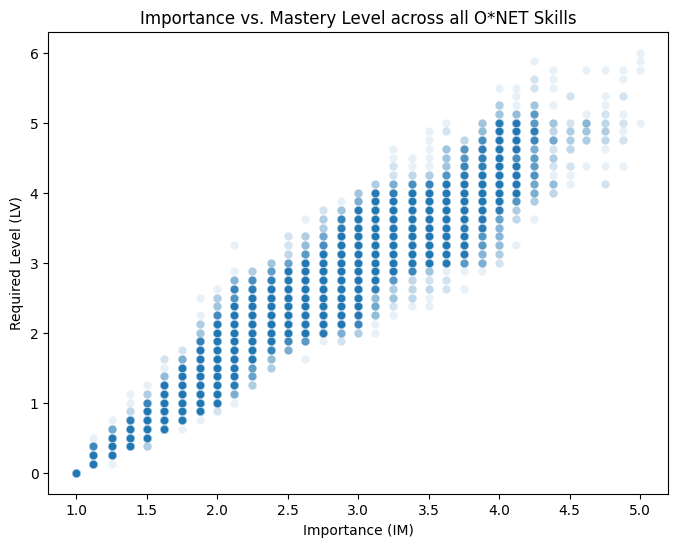

In [4]:
# Pivot to get IM and LV side-by-side
skills_pivot = df_skills.pivot_table(
    index=['O*NET-SOC Code', 'Element ID'], 
    columns='Scale ID', 
    values='Data Value'
).reset_index()

# Plot the distribution
plt.figure(figsize=(8, 6))
sns.scatterplot(x='IM', y='LV', data=skills_pivot, alpha=0.1)
plt.title("Importance vs. Mastery Level across all O*NET Skills")
plt.xlabel("Importance (IM)")
plt.ylabel("Required Level (LV)")
plt.show()

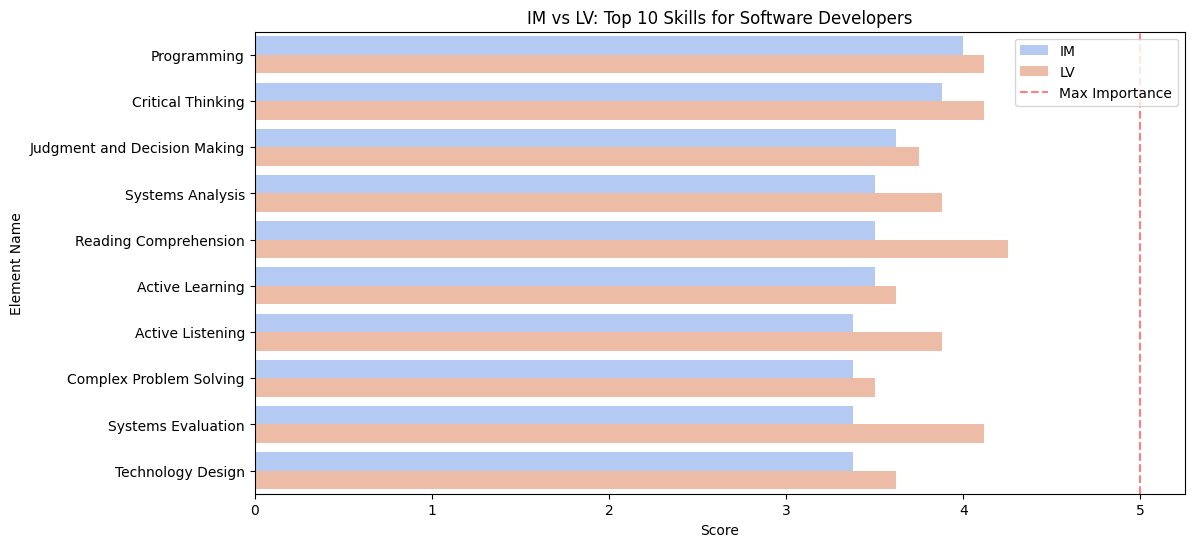

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the data for Software Developers
search_term = "Software Developers"
matches = df_occ[df_occ['Title'].str.contains(search_term, case=False, na=False)]
dev_code = matches.iloc[0]['O*NET-SOC Code']

# 2. Pivot data to get IM and LV as separate columns
job_data = df_skills[df_skills['O*NET-SOC Code'] == dev_code]
pivot_df = job_data.pivot_table(index='Element Name', columns='Scale ID', values='Data Value').reset_index()

# 3. Sort by Importance and take Top 10
top_10 = pivot_df.sort_values(by='IM', ascending=False).head(10)

# 4. Melt for Seaborn (side-by-side plotting)
melted_df = top_10.melt(id_vars='Element Name', value_vars=['IM', 'LV'], var_name='Scale', value_name='Score')

# 5. Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Element Name', hue='Scale', data=melted_df, palette='coolwarm')
plt.title(f"IM vs LV: Top 10 Skills for {search_term}")
plt.axvline(5.0, color='red', linestyle='--', alpha=0.5, label='Max Importance')
plt.legend()
plt.show()